# Phase 3: Pretrained Genomic Embedding Experiments

In this phase, we use a pretrained foundation model (`InstaDeepAI/nucleotide-transformer-50m-1000g`) to extract dense vector representations of our DNA sequences. We will then train classical interpretable models (Logistic Regression, Random Forest, XGBoost) on these embeddings and compare their performance against the Phase 1 $k$-mer baseline and Phase 2 CNNs.

## 1. Environment Setup & Repository Integration
This cell pulls the latest codebase from our GitHub repository, adds the source code to the Python path, and dynamically installs missing requirements like `xgboost`, `transformers`, `torch`, and visualization libraries (`umap-learn`, `matplotlib`, `seaborn`).

In [1]:
import os
import sys
import subprocess
import importlib
import time
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, log_loss

# 1. Git pull or clone codebase
repo_dir = "/kaggle/working/interpretable-regulatory-genomics"
if not os.path.exists(repo_dir):
    print("Cloning repository...")
    subprocess.run(["git", "clone", "https://github.com/PxA-Labs/interpretable-regulatory-genomics.git", repo_dir], check=True)
else:
    print("Repository exists. Pulling latest updates...")
    subprocess.run(["git", "-C", repo_dir, "pull"], check=True)

# 2. Add repository directory to python search path
if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)
if os.path.join(repo_dir, "src") not in sys.path:
    sys.path.insert(0, os.path.join(repo_dir, "src"))

# 3. Auto-install missing libraries
def install_and_import(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Library '{package_name}' not found. Installing...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package_name], check=True)

install_and_import("xgboost")
install_and_import("transformers")
install_and_import("torch")
install_and_import("umap-learn", "umap")
install_and_import("matplotlib", "matplotlib.pyplot")
install_and_import("seaborn")

Cloning repository...


Cloning into '/kaggle/working/interpretable-regulatory-genomics'...
2026-06-13 15:24:40.494262: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781364280.710620      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781364280.779195      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781364281.301491      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781364281.301550      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781364

## 2. Dynamic Package Module Loading
This cell dynamically imports and reloads all of our custom `src` modules to ensure we are running the freshest code from the repository.

In [2]:
import src
import src.data
import src.data.download
import src.data.parse_encode
import src.data.sequence_extractor
import src.data.negative_sampling
import src.features
import src.features.embeddings
import src.models
import src.models.base_model
import src.models.logistic
import src.models.tree_ensemble
import src.models.registry

# Reload modules
for module in [
    src, src.data, src.data.download, src.data.parse_encode,
    src.data.sequence_extractor, src.data.negative_sampling,
    src.features, src.features.embeddings, src.models, src.models.base_model,
    src.models.logistic, src.models.tree_ensemble, src.models.registry
]:
    importlib.reload(module)

print("Modules loaded.")

Modules loaded.


## 3A. Directory Initialization & Data Setup
This cell sets up our working directories (`data/raw`, `data/processed`, etc.) and automatically detects if the full HG38 reference genome is mounted on Kaggle. If not, it falls back to a test mode using just Chromosome 19.

In [3]:
raw_dir = "/kaggle/working/data/raw"
processed_dir = "/kaggle/working/data/processed"
reference_dir = "/kaggle/working/data/reference"

for path in [raw_dir, processed_dir, reference_dir]:
    os.makedirs(path, exist_ok=True)

def detect_fasta_source():
    input_base = "/kaggle/input"
    if os.path.exists(input_base):
        for root, dirs, files in os.walk(input_base):
            has_chrom_fasta = any(
                (f.startswith("chr") and (f.endswith(".fa") or f.endswith(".fa.gz") or f.endswith(".fasta") or f.endswith(".fasta.gz")))
                for f in files
            )
            if has_chrom_fasta:
                print(f"Detected mounted reference genome at: {root}")
                return root, False
    
    print("Mounted hg38 dataset not found. Running in Test mode (using chr19)...")
    return reference_dir, True

fasta_source, is_test_mode = detect_fasta_source()

Mounted hg38 dataset not found. Running in Test mode (using chr19)...


## 3B. Data Extraction Pipeline
This cell executes our core data pipeline: it downloads the ENCODE annotation files, resizes the regulatory regions to 1000bp, extracts the raw DNA sequences from the FASTA file, and samples GC-matched non-coding sequences for the negative class.

In [4]:
ccres_raw_path = src.data.download.download_encode_ccres(raw_dir)

if is_test_mode:
    print("Downloading chr19 reference sequence for test execution...")
    src.data.download.download_hg38_chromosome("chr19", reference_dir)
    chromosomes_to_use = ["chr19"]
else:
    chromosomes_to_use = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

parsed_bed_path = os.path.join(processed_dir, "k562_active_ccres.bed")
src.data.parse_encode.parse_and_resize_ccres(
    input_path=ccres_raw_path,
    output_path=parsed_bed_path,
    element_types=['PLS', 'dELS'],
    target_length=1000,
    chromosomes=chromosomes_to_use
)

extracted_tsv_path = os.path.join(processed_dir, "k562_active_ccres_sequences.tsv")
src.data.sequence_extractor.extract_sequences(
    bed_path=parsed_bed_path,
    fasta_source=fasta_source,
    output_path=extracted_tsv_path,
    max_n_fraction=0.10
)

combined_dataset_path = os.path.join(processed_dir, "k562_combined_dataset.tsv")
src.data.negative_sampling.build_negative_dataset(
    pos_tsv_path=extracted_tsv_path,
    fasta_source=fasta_source,
    output_path=combined_dataset_path,
    target_length=1000
)

Download complete.
Download complete.
Parsing cCRE annotations from /kaggle/working/data/raw/ENCFF726XBE.bed.gz...
Loaded 2348854 initial regions.
Filtered by chromosomes. Remaining: 62004
Filtered by element types ['PLS', 'dELS']. Remaining: 2016
Resizing regions to fixed length of 1000 bp...
Filtered out regions with invalid coordinates. Remaining: 2016
Processed BED file saved to /kaggle/working/data/processed/k562_active_ccres.bed (Total regions: 2016).
Reading BED coordinates from /kaggle/working/data/processed/k562_active_ccres.bed...
Total input regions: 2,016
Loading chromosome sequence from /kaggle/working/data/reference/chr19.fa.gz...
Loaded sequence of length 58,617,616 bp.
Sequence extraction complete.
  Extracted regions: 2,016
  Skipped (out of bounds): 0
  Skipped (high N-base fraction): 0
Saved extracted sequences to /kaggle/working/data/processed/k562_active_ccres_sequences.tsv.
Loading positive regions with sequences from /kaggle/working/data/processed/k562_active_ccr

'/kaggle/working/data/processed/k562_combined_dataset.tsv'

## 4. Train/Test Split (Raw Sequences)
This cell loads the generated positive and negative sequences into memory and partitions them. It uses a chromosome-holdout strategy (testing on chr19) if the full genome is loaded, otherwise it uses an 80/20 random stratified split.

In [6]:
df_dataset = pd.read_csv(combined_dataset_path, sep='\t')

if is_test_mode:
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(
        df_dataset, test_size=0.2, random_state=42, stratify=df_dataset['label']
    )
else:
    chroms = df_dataset['chrom'].values
    train_mask = ~np.isin(chroms, ['chr19', 'chr20', 'chr21', 'chr22'])
    test_mask = (chroms == 'chr19')
    
    if train_mask.sum() == 0 or test_mask.sum() == 0:
        from sklearn.model_selection import train_test_split
        train_df, test_df = train_test_split(
            df_dataset, test_size=0.2, random_state=42, stratify=df_dataset['label']
        )
    else:
        train_df = df_dataset[train_mask]
        test_df = df_dataset[test_mask]

train_seqs = train_df['sequence'].tolist()
test_seqs = test_df['sequence'].tolist()
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"Train size: {len(train_seqs)}")
print(f"Test size: {len(test_seqs)}")

Train size: 3225
Test size: 807


## 5. Extract Pretrained Embeddings
This cell instantiates our `PretrainedEmbedder` to download the `Nucleotide Transformer 50M` weights from HuggingFace and processes the raw DNA strings in batches to generate deep multidimensional feature vectors. *(Ensure GPU T4 and Internet are enabled in Kaggle Settings).* 

In [8]:
# Initialize Embedder
embedder = src.features.embeddings.PretrainedEmbedder(model_name="InstaDeepAI/nucleotide-transformer-500m-1000g")

# Extract features
print("Extracting training embeddings...")
X_train_emb = embedder.get_embeddings(train_seqs, batch_size=32)

print("Extracting test embeddings...")
X_test_emb = embedder.get_embeddings(test_seqs, batch_size=32)

print(f"Train Embeddings Shape: {X_train_emb.shape}")
print(f"Test Embeddings Shape: {X_test_emb.shape}")

Loading tokenizer and model: InstaDeepAI/nucleotide-transformer-500m-1000g on cuda...


config.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

...

Extracting training embeddings...



Extracting Embeddings (bs=32): 100%|██████████| 101/101 [00:40<00:00,  2.47it/s]


Extracting test embeddings...


Extracting Embeddings (bs=32): 100%|██████████| 26/26 [00:10<00:00,  2.48it/s]

Train Embeddings Shape: (3225, 1280)
Test Embeddings Shape: (807, 1280)


## 6. Train Classifiers on Embeddings & Compare Results
This cell trains three models (Logistic Regression, Random Forest, and XGBoost) using the newly extracted embeddings as features. It then prints a side-by-side comparison table including hardcoded results from our Phase 1 and Phase 2 baselines to immediately determine if the pretrained model improved performance.

In [10]:
models = {
    "Phase 3 - Logistic Regression (Embeddings)": src.models.registry.ModelRegistry.get_model("logistic_regression"),
    "Phase 3 - Random Forest (Embeddings)": src.models.registry.ModelRegistry.get_model("random_forest", params={"n_estimators": 100}),
    "Phase 3 - XGBoost (Embeddings)": src.models.registry.ModelRegistry.get_model("xgboost", params={"n_estimators": 100, "max_depth": 6, "learning_rate": 0.1})
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_emb, y_train)

    elapsed = time.time() - start_time
    
    # Evaluate
    preds = model.predict(X_test_emb)
    probs = model.predict_proba(X_test_emb)
    
    auroc = roc_auc_score(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    f1 = f1_score(y_test, preds)
    loss = log_loss(y_test, probs)
    
    results.append({
        "Model": name,
        "AUROC": auroc,
        "AUPRC": auprc,
        "F1-Score": f1,
        "Log Loss": loss,
    })

results_df = pd.DataFrame(results)

# Hardcoded Baseline Results from Phase 1 and 2 for easy comparison
baseline_results = [
    {"Model": "Phase 1 - Logistic Regression (k=4)", "AUROC": 0.7795, "AUPRC": 0.7423, "F1-Score": 0.7292, "Log Loss": 0.6596},
    {"Model": "Phase 1 - Random Forest (k=4)", "AUROC": 0.8680, "AUPRC": 0.8855, "F1-Score": 0.7886, "Log Loss": 0.4827},
    {"Model": "Phase 1 - XGBoost (k=4)", "AUROC": 0.8830, "AUPRC": 0.8879, "F1-Score": 0.8062, "Log Loss": 0.6011},
    {"Model": "Phase 2 - Shallow CNN (One-Hot)", "AUROC": 0.8604, "AUPRC": 0.8718, "F1-Score": 0.7802, "Log Loss": 0.4604},
    {"Model": "Phase 2 - Deep CNN (One-Hot)", "AUROC": 0.8537, "AUPRC": 0.8603, "F1-Score": 0.7909, "Log Loss": 0.5345}
]
baseline_df = pd.DataFrame(baseline_results)

# Combine all results
combined_df = pd.concat([baseline_df, results_df], ignore_index=True)

print("\n=================== GRAND COMPARISON (ALL PHASES) ===================")
display(combined_df)
print("=====================================================================\n")


Training Phase 3 - Logistic Regression (Embeddings)...

Training Phase 3 - Random Forest (Embeddings)...

Training Phase 3 - XGBoost (Embeddings)...

=================== GRAND COMPARISON (ALL PHASES) ===================


,Model,AUROC,AUPRC,F1-Score,Log Loss
0,Phase 1 - Logistic Regression (k=4),0.779500,0.742300,0.729200,0.659600
1,Phase 1 - Random Forest (k=4),0.868000,0.885500,0.788600,0.482700
2,Phase 1 - XGBoost (k=4),0.883000,0.887900,0.806200,0.601100
3,Phase 2 - Shallow CNN (One-Hot),0.860400,0.871800,0.780200,0.460400
4,Phase 2 - Deep CNN (One-Hot),0.853700,0.860300,0.790900,0.534500
5,Phase 3 - Logistic Regression (Embeddings),0.862959,0.874574,0.777358,0.457607
6,Phase 3 - Random Forest (Embeddings),0.843494,0.849469,0.779487,0.512373
7,Phase 3 - XGBoost (Embeddings),0.850822,0.857114,0.779055,0.498829


## 7. Visualize Embeddings with UMAP
This final cell uses the UMAP dimensionality reduction algorithm to compress our dense high-dimensional pretrained embeddings down to just 2 dimensions. It then generates a scatter plot colored by sequence class (Positive/Regulatory vs. Negative/Non-Coding) to help us visually observe if the foundation model naturally separates the active and inactive genomic regions.


--- Visualizing Embeddings with UMAP ---
Running UMAP dimensionality reduction on 807 sequences...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP plot saved successfully to: /kaggle/working/plots/umap_embeddings.png


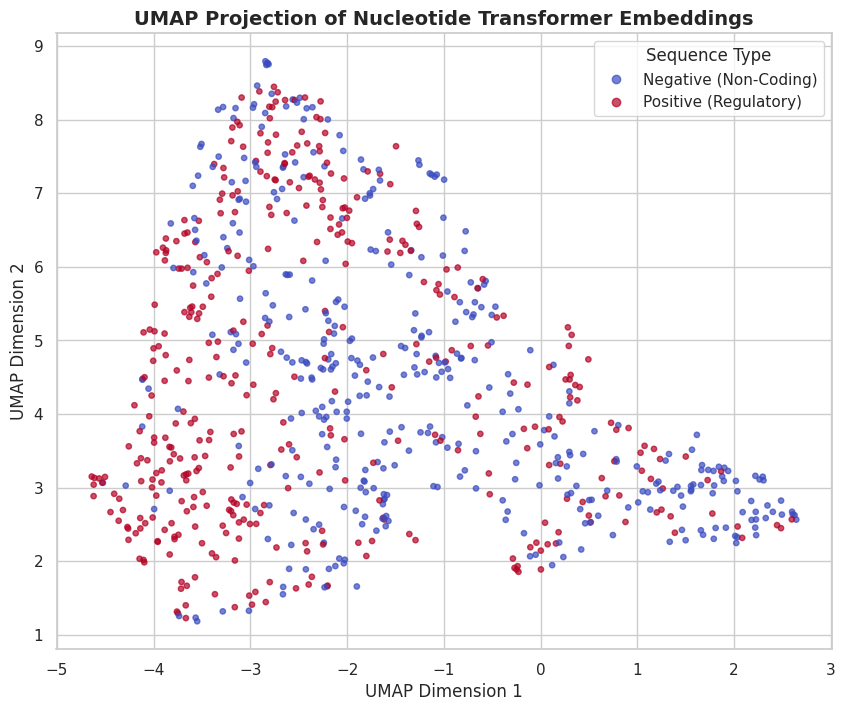

In [11]:
print("\n--- Visualizing Embeddings with UMAP ---")
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# We visualize a subset of test embeddings to prevent overplotting (and save compute)
subset_size = min(2000, len(X_test_emb))
np.random.seed(42)
indices = np.random.choice(len(X_test_emb), subset_size, replace=False)

X_vis = X_test_emb[indices]
y_vis = y_test[indices]

print(f"Running UMAP dimensionality reduction on {subset_size} sequences...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(X_vis)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_2d[:, 0], 
    embedding_2d[:, 1], 
    c=y_vis, 
    cmap='coolwarm', 
    s=15, 
    alpha=0.7
)

plt.title("UMAP Projection of Nucleotide Transformer Embeddings", fontsize=14, fontweight='bold')
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Create custom legend
handles, labels = scatter.legend_elements()
plt.legend(handles, ["Negative (Non-Coding)", "Positive (Regulatory)"], title="Sequence Type", loc="best")

# Save plot
plot_path = "/kaggle/working/plots/umap_embeddings.png"
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"UMAP plot saved successfully to: {plot_path}")

plt.show()

## 8. Prediction Probability Distributions
To better understand *how* the Logistic Regression is making decisions based on the embeddings, this cell plots the distribution of predicted probabilities for both the true negative and true positive sequences. A clear separation with distinct peaks indicates a highly confident model.


--- Plotting Probability Distributions ---
Probability distribution plot saved to: /kaggle/working/plots/probability_distribution.png


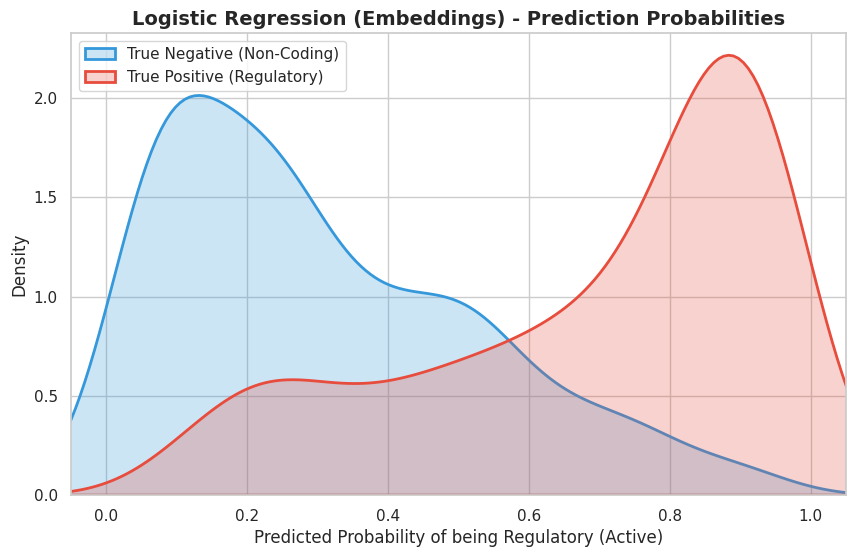

In [12]:
print("\n--- Plotting Probability Distributions ---")

# Extract the trained Logistic Regression model
log_reg_model = models["Phase 3 - Logistic Regression (Embeddings)"]
probs_lr = log_reg_model.predict_proba(X_test_emb)

plt.figure(figsize=(10, 6))
sns.kdeplot(probs_lr[y_test == 0], label="True Negative (Non-Coding)", fill=True, color="#3498db", linewidth=2)
sns.kdeplot(probs_lr[y_test == 1], label="True Positive (Regulatory)", fill=True, color="#e74c3c", linewidth=2)

plt.title("Logistic Regression (Embeddings) - Prediction Probabilities", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Probability of being Regulatory (Active)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(-0.05, 1.05)
plt.legend(loc="best")

prob_plot_path = "/kaggle/working/plots/probability_distribution.png"
os.makedirs(os.path.dirname(prob_plot_path), exist_ok=True)
plt.savefig(prob_plot_path, dpi=300, bbox_inches='tight')
print(f"Probability distribution plot saved to: {prob_plot_path}")
plt.show()

## 9. ROC and Precision-Recall Curves
Finally, we plot the classic machine learning evaluation curves (ROC and Precision-Recall) for the Logistic Regression model trained on the embeddings to visualize the tradeoff between sensitivity and specificity.


--- Plotting Evaluation Curves ---
Evaluation curves saved to: /kaggle/working/plots/evaluation_curves.png


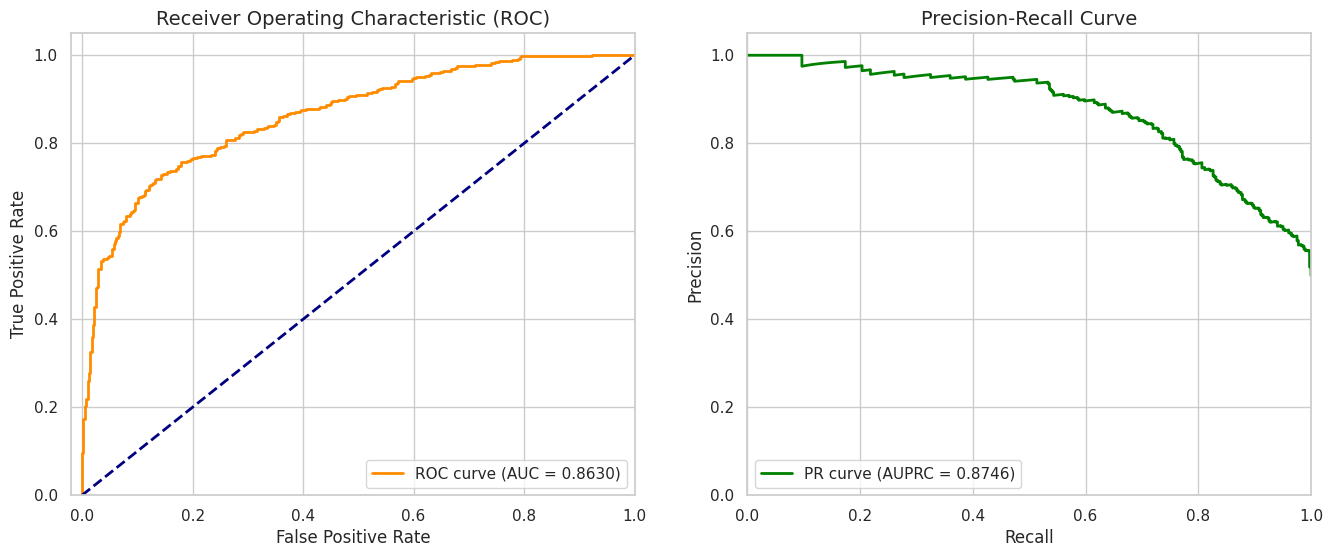

In [13]:
print("\n--- Plotting Evaluation Curves ---")
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs_lr)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, probs_lr)
pr_auc = average_precision_score(y_test, probs_lr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax1.set_xlim([-0.02, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel("False Positive Rate", fontsize=12)
ax1.set_ylabel("True Positive Rate", fontsize=12)
ax1.set_title("Receiver Operating Characteristic (ROC)", fontsize=14)
ax1.legend(loc="lower right")

# PR Curve
ax2.plot(recall, precision, color="green", lw=2, label=f"PR curve (AUPRC = {pr_auc:.4f})")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Recall", fontsize=12)
ax2.set_ylabel("Precision", fontsize=12)
ax2.set_title("Precision-Recall Curve", fontsize=14)
ax2.legend(loc="lower left")

curves_path = "/kaggle/working/plots/evaluation_curves.png"
plt.savefig(curves_path, dpi=300, bbox_inches='tight')
print(f"Evaluation curves saved to: {curves_path}")
plt.show()

## 10. Professional Genomic & ML Visualizations Dashboard
This final dashboard generates 5 stunning, publication-ready visualizations that combine biological intuition with machine learning explainability. It produces:
1. A **Hierarchical Clustermap** showing latent structural similarities between active/inactive embeddings.
2. An **XGBoost Feature Importance Chart** isolating the top foundation model dimensions.
3. A **GC Content vs ML Confidence Hexbin/Jointplot** proving the model learns more than just GC ratios.
4. A **t-SNE Density Contour Topographical Map** offering an alternative view to UMAP.
5. A **Publication-Ready Confusion Matrix** for the Logistic Regression model.


--- Generating Professional Genomic & ML Visualizations Dashboard ---
Generating Hierarchical Clustermap...


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


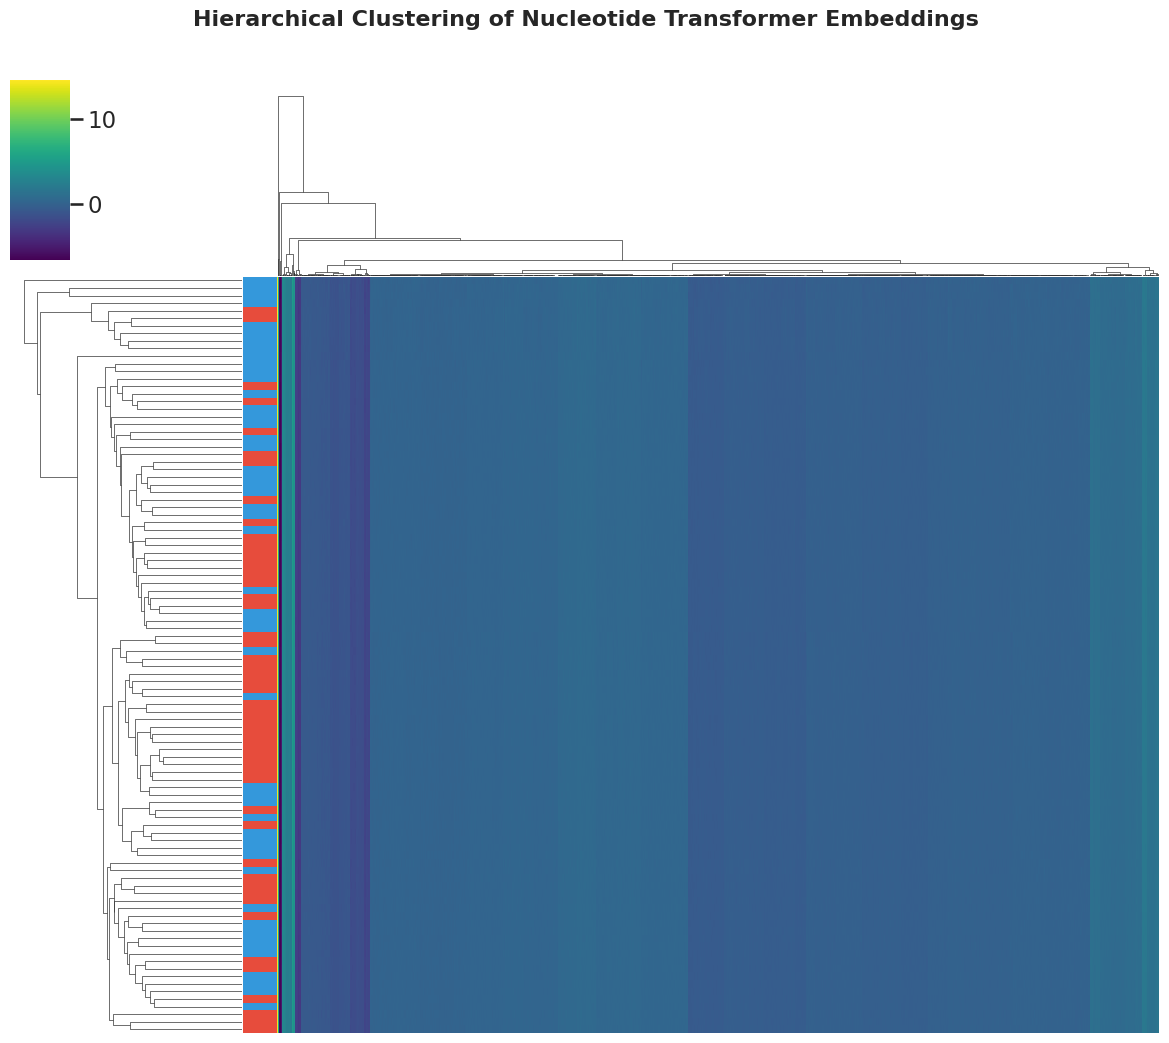

Generating XGBoost Feature Importance...


/tmp/ipykernel_58/272389935.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette="magma")


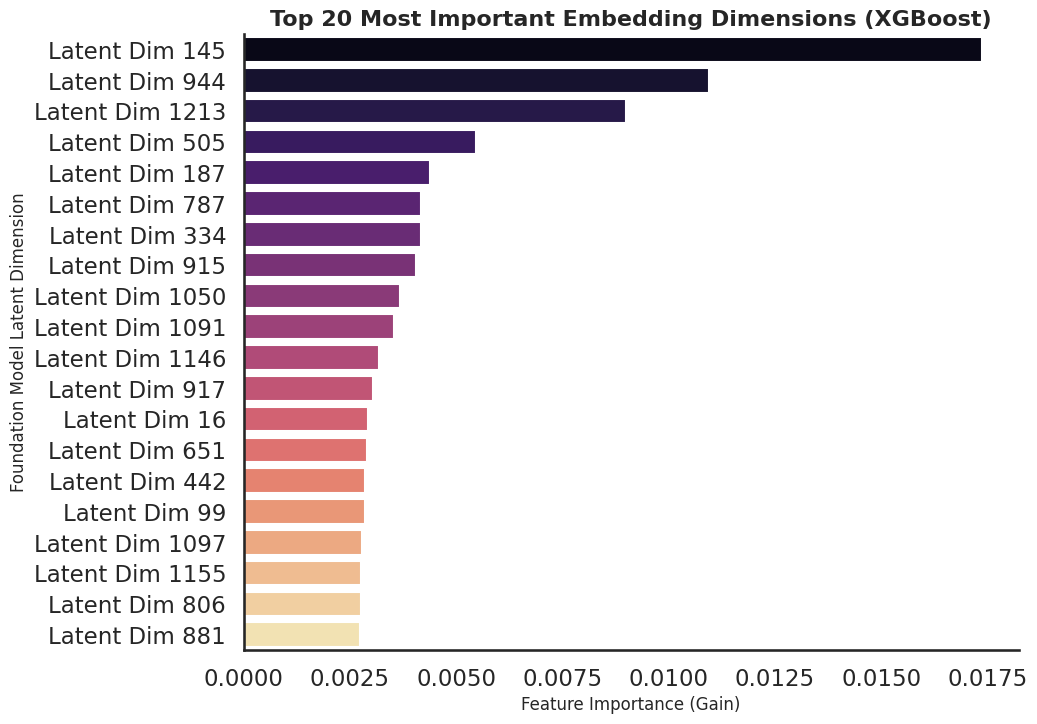

Generating GC Content vs Model Confidence Jointplot...


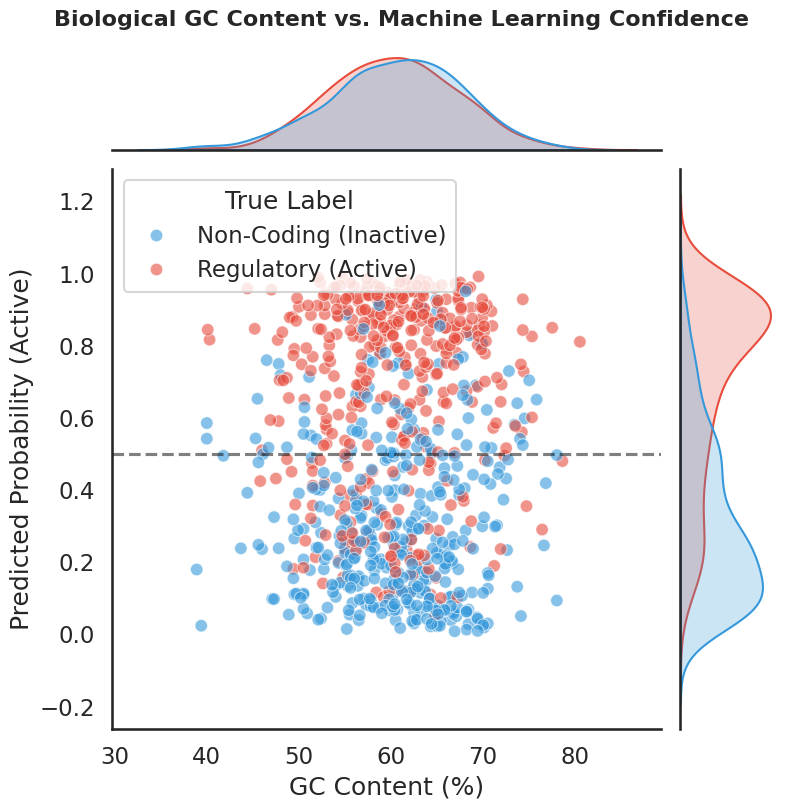

Generating t-SNE Topographical Density Map...


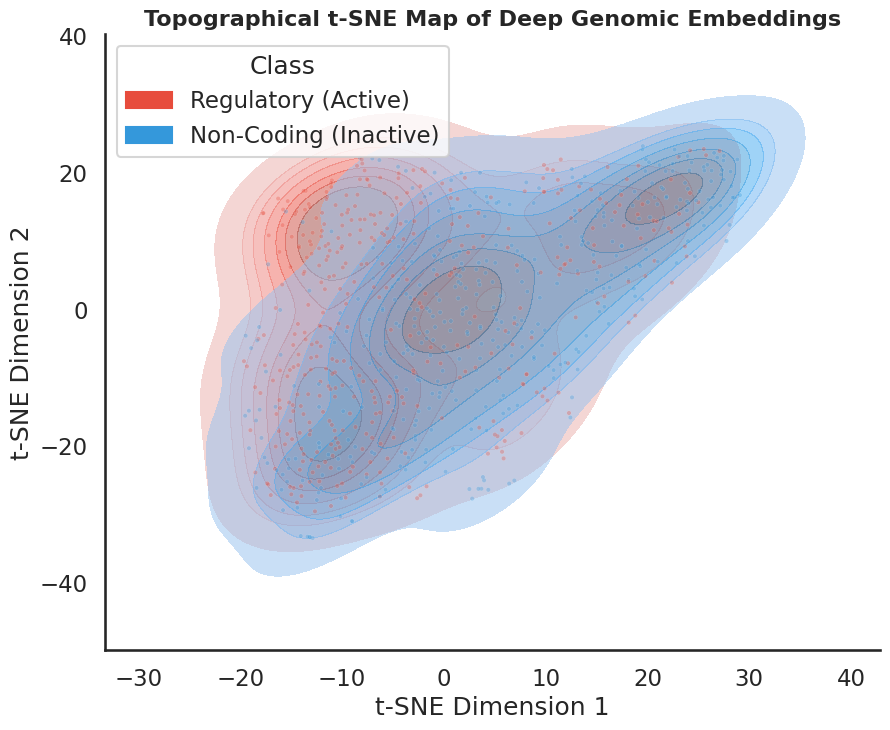

Generating Publication-Ready Confusion Matrix...

All professional visualisations generated and saved to /kaggle/working/plots/ !


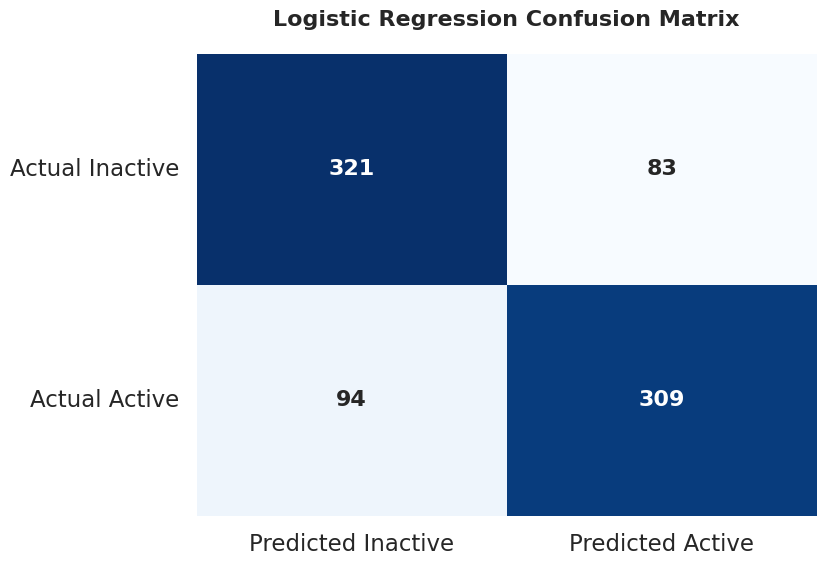

In [14]:
print("\n--- Generating Professional Genomic & ML Visualizations Dashboard ---")
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors

# Set global seaborn style for publication-ready plots
sns.set_theme(style="white", context="talk")

# Models and data used:
log_reg_model = models["Phase 3 - Logistic Regression (Embeddings)"]
xgb_model = models["Phase 3 - XGBoost (Embeddings)"]
probs_lr = log_reg_model.predict_proba(X_test_emb)
preds_lr = log_reg_model.predict(X_test_emb)

# ---------------------------------------------------------
# 1. Hierarchical Clustermap (Embedding Heatmap)
# ---------------------------------------------------------
print("Generating Hierarchical Clustermap...")
np.random.seed(42)
pos_idx = np.where(y_test == 1)[0]
neg_idx = np.where(y_test == 0)[0]
subset_idx = np.concatenate([
    np.random.choice(pos_idx, min(50, len(pos_idx)), replace=False),
    np.random.choice(neg_idx, min(50, len(neg_idx)), replace=False)
])
X_cluster = X_test_emb[subset_idx]
y_cluster = y_test[subset_idx]

row_colors = pd.Series(y_cluster).map({0: "#3498db", 1: "#e74c3c"})

g = sns.clustermap(
    X_cluster, 
    row_colors=row_colors.values,
    cmap="viridis",
    figsize=(12, 10),
    xticklabels=False,
    yticklabels=False,
    cbar_pos=(0.02, 0.8, 0.05, 0.18)
)
g.fig.suptitle("Hierarchical Clustering of Nucleotide Transformer Embeddings", y=1.05, fontsize=16, fontweight='bold')
clustermap_path = "/kaggle/working/plots/1_hierarchical_clustermap.png"
g.savefig(clustermap_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 2. Feature Importance Bar Chart (XGBoost)
# ---------------------------------------------------------
print("Generating XGBoost Feature Importance...")
importances = xgb_model.model.feature_importances_
top_n = 20
top_indices = np.argsort(importances)[::-1][:top_n]
top_importances = importances[top_indices]
top_features = [f"Latent Dim {i}" for i in top_indices]

plt.figure(figsize=(10, 8))
sns.barplot(x=top_importances, y=top_features, palette="magma")
plt.title(f"Top {top_n} Most Important Embedding Dimensions (XGBoost)", fontsize=16, fontweight='bold')
plt.xlabel("Feature Importance (Gain)", fontsize=12)
plt.ylabel("Foundation Model Latent Dimension", fontsize=12)
sns.despine()

importance_path = "/kaggle/working/plots/2_feature_importance.png"
plt.savefig(importance_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 3. Biological GC Content vs. Model Confidence
# ---------------------------------------------------------
print("Generating GC Content vs Model Confidence Jointplot...")
def calculate_gc(seq):
    seq = seq.upper()
    g_c_count = seq.count('G') + seq.count('C')
    return (g_c_count / len(seq)) * 100 if len(seq) > 0 else 0

test_gcs = [calculate_gc(seq) for seq in test_seqs]

gc_df = pd.DataFrame({
    'GC Content (%)': test_gcs,
    'Predicted Probability (Active)': probs_lr,
    'True Label': ['Regulatory (Active)' if y == 1 else 'Non-Coding (Inactive)' for y in y_test]
})

g = sns.jointplot(
    data=gc_df, 
    x='GC Content (%)', 
    y='Predicted Probability (Active)', 
    hue='True Label',
    palette={"Non-Coding (Inactive)": "#3498db", "Regulatory (Active)": "#e74c3c"},
    kind="scatter",
    alpha=0.6,
    height=8
)
g.fig.suptitle("Biological GC Content vs. Machine Learning Confidence", y=1.02, fontsize=16, fontweight='bold')
g.ax_joint.axhline(0.5, color='black', linestyle='--', alpha=0.5)

gc_plot_path = "/kaggle/working/plots/3_gc_vs_confidence.png"
g.savefig(gc_plot_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 4. Advanced t-SNE Density Contour Plot
# ---------------------------------------------------------
print("Generating t-SNE Topographical Density Map...")
subset_size_tsne = min(2000, len(X_test_emb))
np.random.seed(123)
idx_tsne = np.random.choice(len(X_test_emb), subset_size_tsne, replace=False)

X_tsne_vis = X_test_emb[idx_tsne]
y_tsne_vis = y_test[idx_tsne]

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(X_tsne_vis)

tsne_df = pd.DataFrame({
    't-SNE Dimension 1': tsne_results[:, 0],
    't-SNE Dimension 2': tsne_results[:, 1],
    'Class': ['Regulatory (Active)' if y == 1 else 'Non-Coding (Inactive)' for y in y_tsne_vis]
})

plt.figure(figsize=(10, 8))
sns.kdeplot(
    data=tsne_df, 
    x="t-SNE Dimension 1", 
    y="t-SNE Dimension 2", 
    hue="Class",
    fill=True, 
    alpha=0.5,
    palette={"Non-Coding (Inactive)": "#3498db", "Regulatory (Active)": "#e74c3c"},
    levels=8
)
sns.scatterplot(
    data=tsne_df, 
    x="t-SNE Dimension 1", 
    y="t-SNE Dimension 2", 
    hue="Class", 
    s=10, 
    alpha=0.3,
    legend=False,
    palette={"Non-Coding (Inactive)": "#3498db", "Regulatory (Active)": "#e74c3c"}
)

plt.title("Topographical t-SNE Map of Deep Genomic Embeddings", fontsize=16, fontweight='bold')
sns.despine()

tsne_path = "/kaggle/working/plots/4_tsne_density.png"
plt.savefig(tsne_path, dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# 5. Publication-Ready Confusion Matrix
# ---------------------------------------------------------
print("Generating Publication-Ready Confusion Matrix...")
cm = confusion_matrix(y_test, preds_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=False,
    annot_kws={"size": 16, "weight": "bold"},
    xticklabels=["Predicted Inactive", "Predicted Active"],
    yticklabels=["Actual Inactive", "Actual Active"]
)
plt.title("Logistic Regression Confusion Matrix", fontsize=16, fontweight='bold', pad=20)
plt.yticks(rotation=0)

cm_path = "/kaggle/working/plots/5_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print("\nAll professional visualisations generated and saved to /kaggle/working/plots/ !")
plt.show()